# 02. Descriptive Statistics

**Objective**: Generate comprehensive descriptive statistics for panel data

This notebook covers:
1. Loading processed data
2. Overall descriptive statistics
3. Between and within variation analysis
4. Correlation analysis
5. Time series trends
6. Cross-sectional variation

In [16]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

# Add src to path
sys.path.append('..')

from src.data.loader import DataLoader
from src.utils.config import ConfigManager

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Data and Configuration

In [17]:
# Load configuration
config_manager = ConfigManager(config_dir='../config')
variables = config_manager.get_variable_info()

# Initialize loader
loader = DataLoader()

# Load data from JSON (created in notebook 01)
data = loader.load_json('../data/processed/audit_data.json')

# Get variable names
entity_col = variables['panel_structure']['entity_variable']
time_col = variables['panel_structure']['time_variable']
dep_var = variables['dependent_variable']['name']
indep_vars = [v['name'] for v in variables['independent_variables']]
control_vars = [v['name'] for v in variables['control_variables']]
all_vars = [dep_var] + indep_vars + control_vars

print(f"Data loaded: {len(data)} observations")
print(f"Entities: {data[entity_col].nunique()}")
print(f"Time periods: {sorted(data[time_col].unique())}")

Loading JSON file: ..\data\processed\audit_data.json
Loaded 252 rows and 8 columns
Data loaded: 252 observations
Entities: 63
Time periods: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


## 2. Overall Descriptive Statistics

Calculate mean, standard deviation, min, max, and quartiles for all variables.

In [18]:
# Overall descriptive statistics
desc_stats = data[all_vars].describe().T
desc_stats['skewness'] = data[all_vars].skew()
desc_stats['kurtosis'] = data[all_vars].kurtosis()

print("\n" + "="*80)
print("OVERALL DESCRIPTIVE STATISTICS")
print("="*80)
print(desc_stats.round(4))

# Save to CSV
desc_stats.to_csv('../results/descriptive_stats_overall.csv')
print("\n✓ Saved to: results/descriptive_stats_overall.csv")


OVERALL DESCRIPTIVE STATISTICS
        count    mean      std        min     25%     50%     75%       max  \
AQMS 252.0000  1.5476   1.0682     0.0000  1.0000  1.0000  3.0000    4.0000   
ARL  252.0000  4.4509   0.2584     3.8070  4.3910  4.4660  4.4890    6.0380   
FEE  252.0000 22.6461   1.6536    17.4530 21.4812 22.5120 23.8582   26.5010   
FO   252.0000  0.1934   0.2808     0.0000  0.0000  0.0000  0.4200    0.9200   
SIZE 252.0000 28.4162   2.0545    17.9830 27.2598 28.5560 29.6505   32.9380   
ROA  252.0000  8.8684 244.1769 -1391.1500  0.0075  0.0500  0.1000 3612.4400   

      skewness  kurtosis  
AQMS    0.2110   -1.1321  
ARL     1.2503    7.5161  
FEE     0.0541   -0.2469  
FO      1.1204   -0.2966  
SIZE   -1.0258    4.0641  
ROA    12.1514  194.9367  

✓ Saved to: results/descriptive_stats_overall.csv


## 3. Panel Data Variation Decomposition

Panel data has three types of variation:
- **Overall**: Total variation across all observations
- **Between**: Variation across entities (companies)
- **Within**: Variation within entities over time

In [19]:
# Calculate panel data variation components
variation_results = []

for var in all_vars:
    # Overall variation
    overall_mean = data[var].mean()
    overall_std = data[var].std()
    
    # Between variation (across entities)
    entity_means = data.groupby(entity_col)[var].mean()
    between_std = entity_means.std()
    
    # Within variation (within entities over time)
    data_demeaned = data.copy()
    data_demeaned[f'{var}_demeaned'] = data.groupby(entity_col)[var].transform(lambda x: x - x.mean())
    within_std = data_demeaned[f'{var}_demeaned'].std()
    
    variation_results.append({
        'Variable': var,
        'Overall_Mean': overall_mean,
        'Overall_SD': overall_std,
        'Between_SD': between_std,
        'Within_SD': within_std,
        'Between_Within_Ratio': between_std / within_std if within_std > 0 else np.nan
    })

variation_df = pd.DataFrame(variation_results)

print("\n" + "="*80)
print("PANEL DATA VARIATION DECOMPOSITION")
print("="*80)
print(variation_df.round(4))
print("\nInterpretation:")
print("- Between_SD: Variation across companies (cross-sectional)")
print("- Within_SD: Variation within companies over time (time-series)")
print("- Ratio > 1: More variation between companies than within")
print("- Ratio < 1: More variation over time than across companies")

# Save to CSV
variation_df.to_csv('../results/panel_variation_decomposition.csv', index=False)
print("\n✓ Saved to: results/panel_variation_decomposition.csv")


PANEL DATA VARIATION DECOMPOSITION
  Variable  Overall_Mean  Overall_SD  Between_SD  Within_SD  \
0     AQMS        1.5476      1.0682      1.0069     0.3734   
1      ARL        4.4509      0.2584      0.2090     0.1537   
2      FEE       22.6461      1.6536      1.5933     0.4754   
3       FO        0.1934      0.2808      0.2776     0.0522   
4     SIZE       28.4162      2.0545      1.9905     0.5534   
5      ROA        8.8684    244.1769     69.9532   234.0671   

   Between_Within_Ratio  
0                2.6964  
1                1.3596  
2                3.3517  
3                5.3156  
4                3.5970  
5                0.2989  

Interpretation:
- Between_SD: Variation across companies (cross-sectional)
- Within_SD: Variation within companies over time (time-series)
- Ratio > 1: More variation between companies than within
- Ratio < 1: More variation over time than across companies

✓ Saved to: results/panel_variation_decomposition.csv


## 4. Correlation Analysis

Examine correlations between all variables to identify potential multicollinearity issues.


CORRELATION MATRIX
        AQMS     ARL     FEE      FO    SIZE     ROA
AQMS  1.0000 -0.2772  0.5134  0.0644  0.4541 -0.0735
ARL  -0.2772  1.0000 -0.3256 -0.1548 -0.1465  0.0264
FEE   0.5134 -0.3256  1.0000 -0.0958  0.6343 -0.0092
FO    0.0644 -0.1548 -0.0958  1.0000  0.0310  0.0305
SIZE  0.4541 -0.1465  0.6343  0.0310  1.0000 -0.1859
ROA  -0.0735  0.0264 -0.0092  0.0305 -0.1859  1.0000


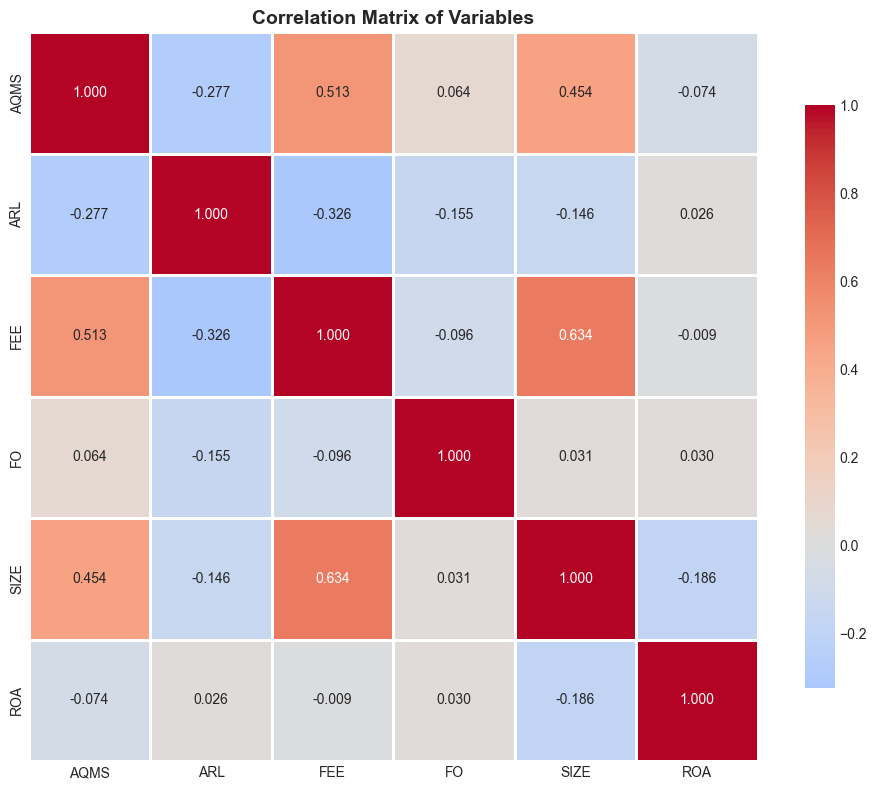


✓ Correlation matrix saved to: results/correlation_matrix.png

High Correlations (|r| > 0.7):
No high correlations detected.


In [20]:
# Correlation matrix
corr_matrix = data[all_vars].corr()

print("\n" + "="*80)
print("CORRELATION MATRIX")
print("="*80)
print(corr_matrix.round(4))

# Visualize correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Correlation matrix saved to: results/correlation_matrix.png")

# Identify high correlations (potential multicollinearity)
print("\nHigh Correlations (|r| > 0.7):")
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr.append({
                'Var1': corr_matrix.columns[i],
                'Var2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

if high_corr:
    high_corr_df = pd.DataFrame(high_corr)
    print(high_corr_df)
else:
    print("No high correlations detected.")

## 5. Descriptive Statistics by Year

Analyze how variables change over time.


DESCRIPTIVE STATISTICS BY YEAR

AQMS:
      count   mean    std  min  max
YEAR                               
2021     63 1.5873 0.9777    0    3
2022     63 1.4921 1.0140    0    3
2023     63 1.5714 1.1600    0    4
2024     63 1.5397 1.1334    0    4

ARL:
      count   mean    std    min    max
YEAR                                   
2021     63 4.5386 0.3209 3.8920 6.0380
2022     63 4.4583 0.2794 3.9320 5.7170
2023     63 4.4177 0.2103 3.9120 5.1530
2024     63 4.3889 0.1796 3.8070 4.8280

FEE:
      count    mean    std     min     max
YEAR                                      
2021     63 22.5236 1.6785 19.3450 26.5010
2022     63 22.6382 1.5830 18.8730 26.5010
2023     63 22.7269 1.6126 19.1410 26.5010
2024     63 22.6956 1.7666 17.4530 26.5010

FO:
      count   mean    std    min    max
YEAR                                   
2021     63 0.1878 0.2745 0.0000 0.9200
2022     63 0.1883 0.2810 0.0000 0.9200
2023     63 0.1967 0.2861 0.0000 0.9200
2024     63 0.2010 0.2881 0.00

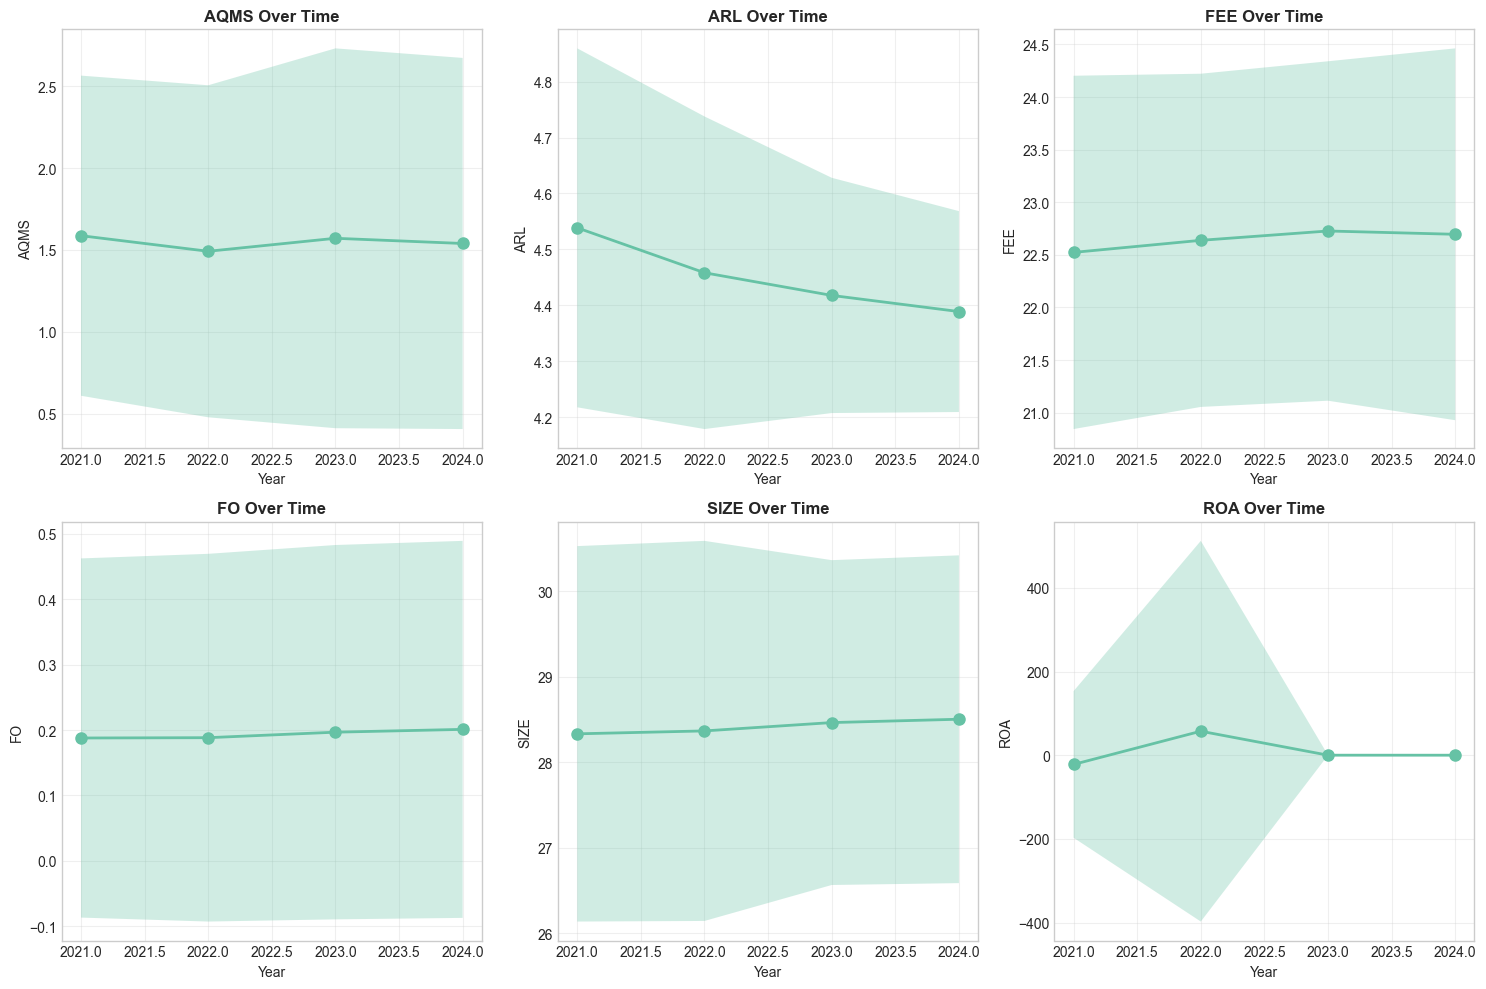


✓ Time trends plot saved to: results/time_trends.png


In [21]:
# Descriptive statistics by year
print("\n" + "="*80)
print("DESCRIPTIVE STATISTICS BY YEAR")
print("="*80)

for var in all_vars:
    print(f"\n{var}:")
    yearly_stats = data.groupby(time_col)[var].agg(['count', 'mean', 'std', 'min', 'max'])
    print(yearly_stats.round(4))

# Visualize trends over time
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, var in enumerate(all_vars):
    yearly_mean = data.groupby(time_col)[var].mean()
    yearly_std = data.groupby(time_col)[var].std()
    
    axes[i].plot(yearly_mean.index, yearly_mean.values, marker='o', linewidth=2, markersize=8)
    axes[i].fill_between(yearly_mean.index, 
                          yearly_mean - yearly_std, 
                          yearly_mean + yearly_std, 
                          alpha=0.3)
    axes[i].set_title(f'{var} Over Time', fontweight='bold')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel(var)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/time_trends.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Time trends plot saved to: results/time_trends.png")

## 6. Descriptive Statistics by Entity (Top 10)

Show variation across companies.

In [22]:
# Descriptive statistics by entity (top 10 by mean AQMS)
entity_means = data.groupby(entity_col)[dep_var].mean().sort_values(ascending=False).head(10)

print("\n" + "="*80)
print(f"TOP 10 COMPANIES BY AVERAGE {dep_var}")
print("="*80)

for entity in entity_means.index:
    entity_data = data[data[entity_col] == entity]
    print(f"\n{entity}:")
    print(entity_data[all_vars].describe().T[['mean', 'std', 'min', 'max']].round(4))


TOP 10 COMPANIES BY AVERAGE AQMS

INDF:
        mean    std     min     max
AQMS  3.5000 0.5774  3.0000  4.0000
ARL   4.4395 0.0291  4.4070  4.4770
FEE  25.4143 0.0863 25.3410 25.5340
FO    0.0000 0.0000  0.0000  0.0000
SIZE 32.8610 0.0543 32.8200 32.9380
ROA   0.0625 0.0096  0.0500  0.0700

BISI:
        mean    std     min     max
AQMS  3.0000 0.0000  3.0000  3.0000
ARL   4.4652 0.1002  4.3440  4.5850
FEE  23.5025 0.5188 22.9510 24.0920
FO    0.2275 0.0519  0.1900  0.3000
SIZE 28.8862 0.0932 28.7730 28.9920
ROA   0.7725 0.0287  0.7400  0.8100

AISA:
        mean    std     min     max
AQMS  3.0000 0.0000  3.0000  3.0000
ARL   4.5013 0.1996  4.2770  4.7620
FEE  23.7322 0.4579 23.3370 24.3280
FO    0.0000 0.0000  0.0000  0.0000
SIZE 28.2455 0.0453 28.1970 28.3060
ROA   0.0050 0.0289 -0.0300  0.0400

CPRO:
        mean    std     min     max
AQMS  3.0000 0.0000  3.0000  3.0000
ARL   4.5468 0.1575  4.4310  4.7790
FEE  24.6582 0.1459 24.5140 24.8600
FO    0.2575 0.0709  0.2100  0.3600
SI

## 7. Distribution Visualizations

Visualize the distribution of all variables.

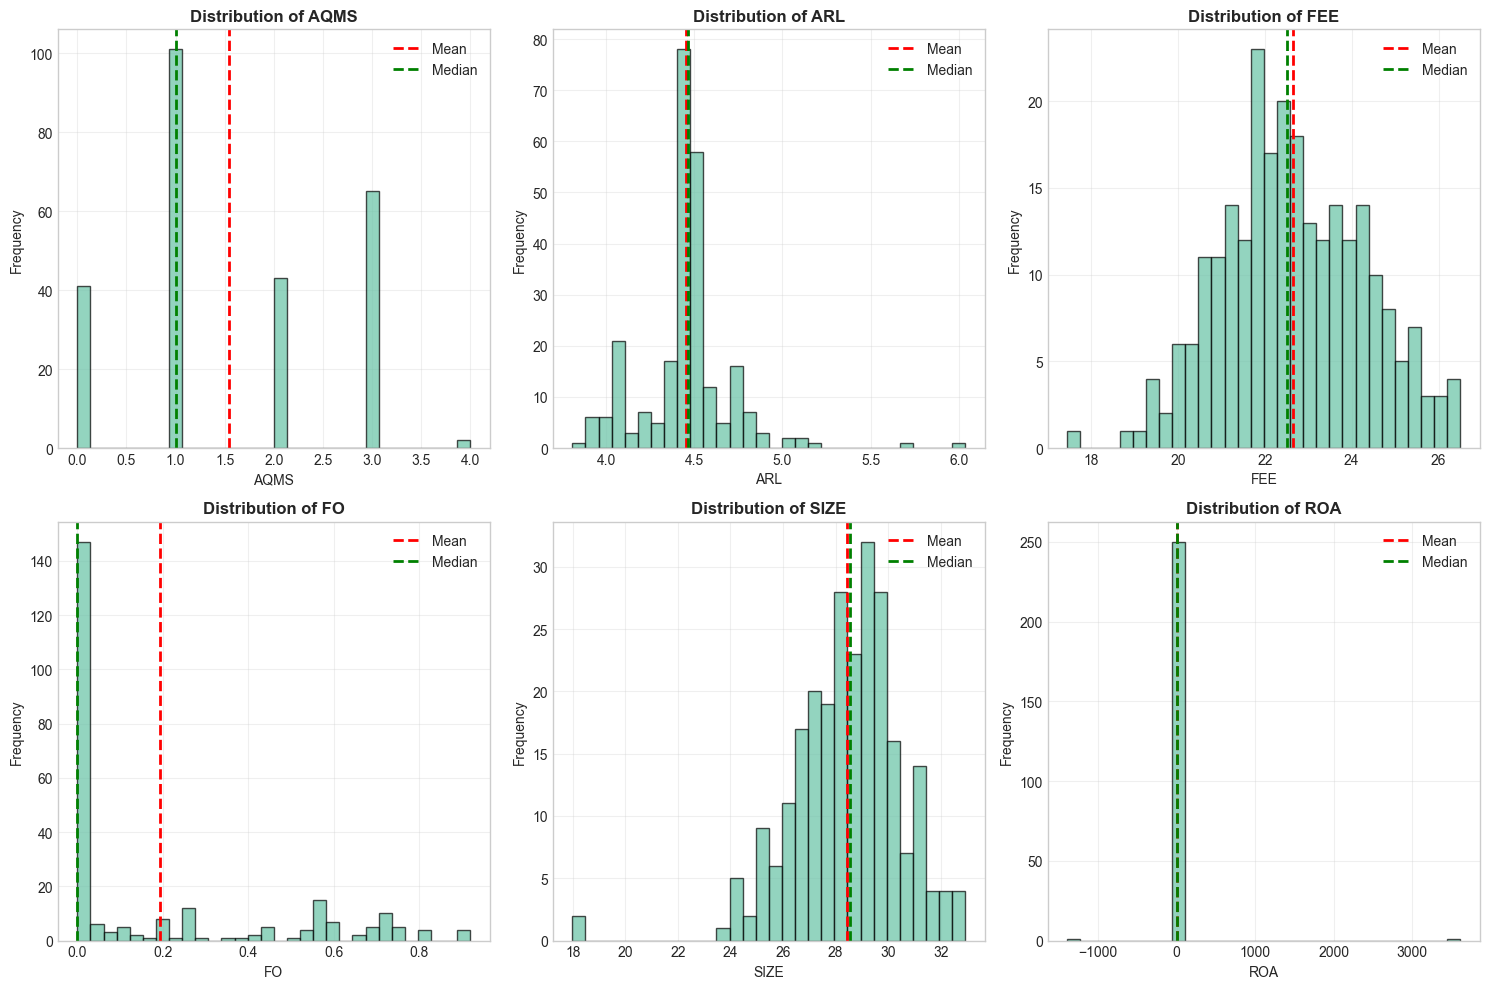


✓ Distribution plots saved to: results/variable_distributions.png


In [23]:
# Distribution plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, var in enumerate(all_vars):
    axes[i].hist(data[var], bins=30, edgecolor='black', alpha=0.7)
    axes[i].axvline(data[var].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
    axes[i].axvline(data[var].median(), color='green', linestyle='--', linewidth=2, label='Median')
    axes[i].set_title(f'Distribution of {var}', fontweight='bold')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frequency')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/variable_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Distribution plots saved to: results/variable_distributions.png")

## 8. Box Plots by Year

Visualize distributions and outliers by year.

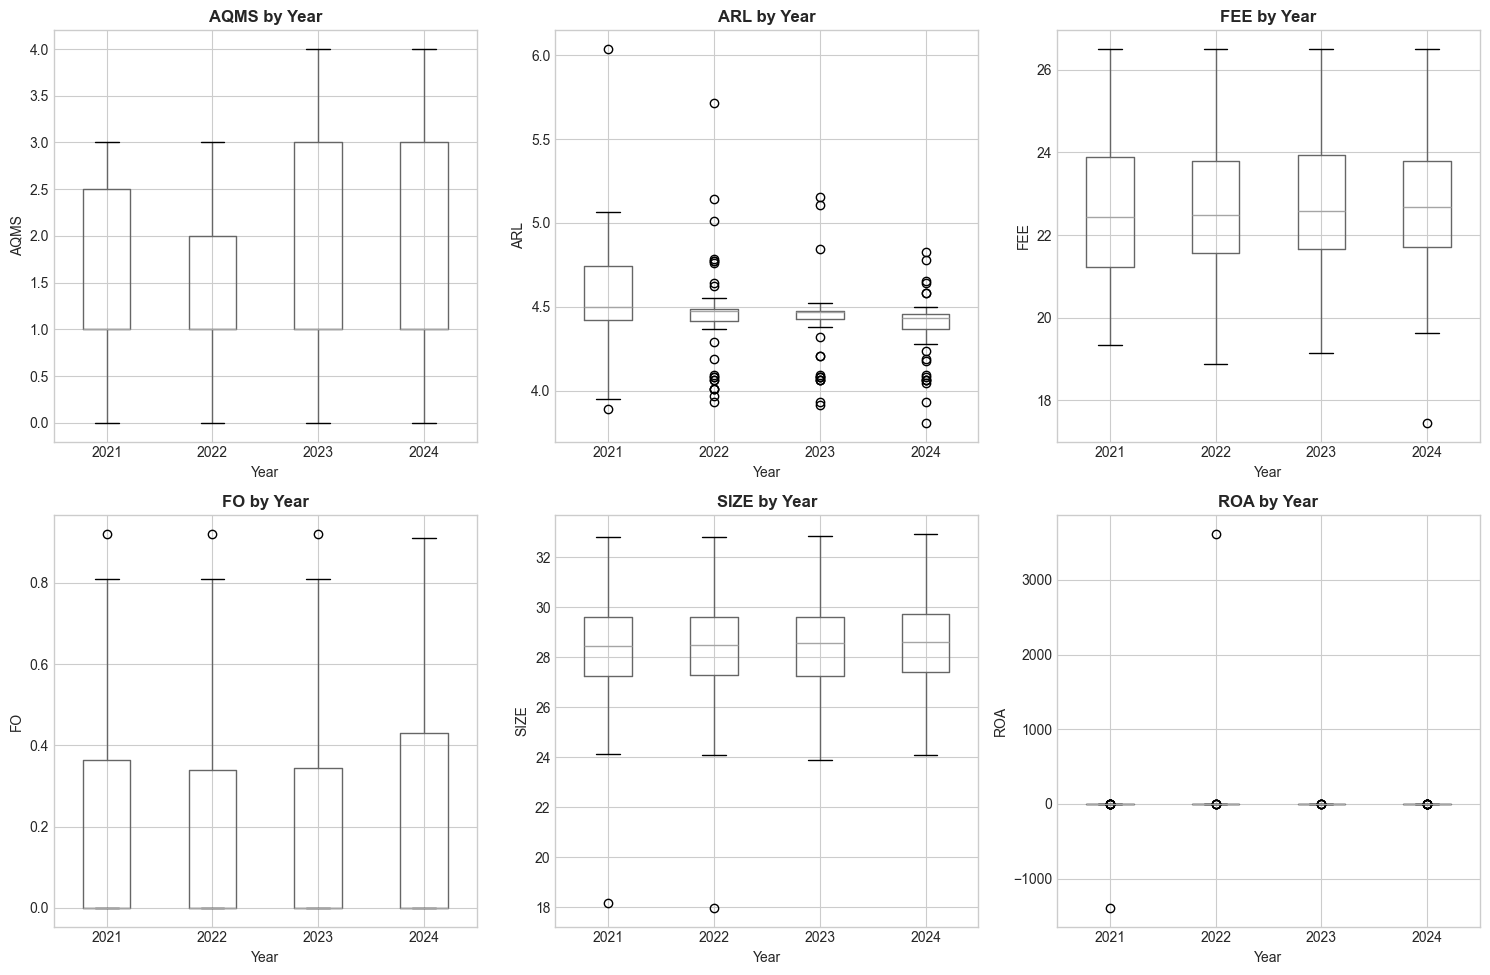


✓ Box plots saved to: results/boxplots_by_year.png


In [24]:
# Box plots by year
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, var in enumerate(all_vars):
    data.boxplot(column=var, by=time_col, ax=axes[i])
    axes[i].set_title(f'{var} by Year', fontweight='bold')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel(var)
    axes[i].get_figure().suptitle('')  # Remove automatic title

plt.tight_layout()
plt.savefig('../results/boxplots_by_year.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Box plots saved to: results/boxplots_by_year.png")

## Summary

This notebook provided comprehensive descriptive statistics:
- ✓ Overall descriptive statistics (mean, SD, quartiles, skewness, kurtosis)
- ✓ Panel variation decomposition (between vs. within)
- ✓ Correlation analysis
- ✓ Temporal trends (2021-2024)
- ✓ Cross-sectional variation
- ✓ Distribution visualizations

**Key Findings to Report in Thesis**:
1. Sample characteristics (N, entities, time periods)
2. Variable distributions (normal vs. skewed)
3. Between vs. within variation ratios
4. Correlation patterns (potential multicollinearity)
5. Time trends in key variables

**Next Steps**:
1. Run `03_diagnostic_tests.ipynb` to test classical assumptions
2. Use correlation matrix to anticipate multicollinearity issues
3. Consider transformations if distributions are highly skewed